# Approximate Bayesian Computation

Also known as likelihood-free inference. 


This notebook contains implementations of some ABC algorithms. 

These are tested with the SIR model.


In [21]:
import numpy as np
import matplotlib.pyplot as plt
import elfi

warning in stationary: failed to import cython module: falling back to numpy
warning in coregionalize: failed to import cython module: falling back to numpy
warning in choleskies: failed to import cython module: falling back to numpy


In [16]:
%run SIR.py

In [23]:
from elfi.examples import lotka_volterra

lv_model = lotka_volterra.get_model()

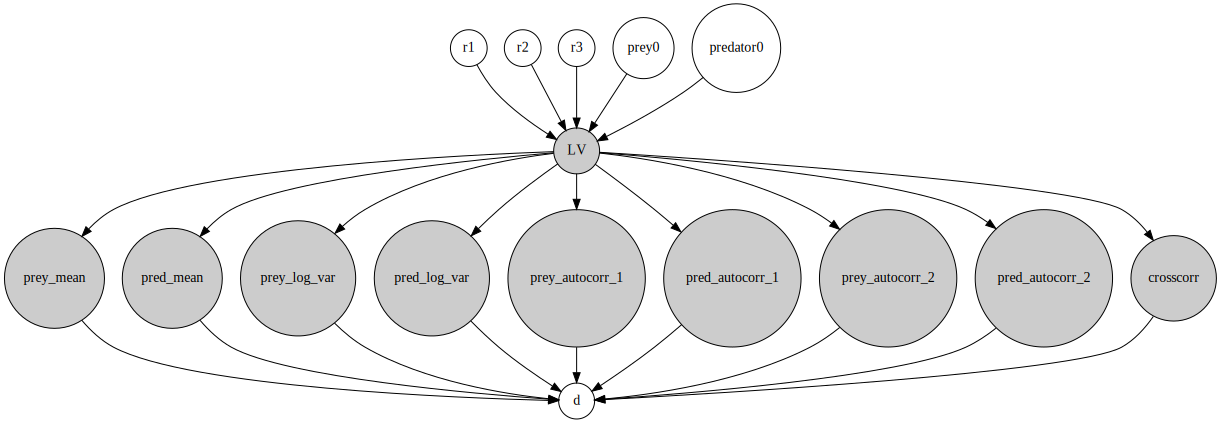

In [26]:
elfi.draw(lv_model)

In [20]:
# Rejection Sampling for SIR

N = 10000
max_iter = 1000 # max number of iterations per i in N
thetas = np.zeros(N)

gamma_prior = np.random.normal(0.4, 0.5, size = 100)
beta_prior = np.random.normal(2, 1, size = 100)
y_0 = SIR(beta_prior, gamma_prior, T = 1000)
print(y_0)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



In [19]:
for i in range(0,N):
    
    n_iter = 0
    gamma_prior = np.random.normal(0.4, 0.5, size = 100)
    beta_prior = np.random.normal(2, 1, size = 100)
    y_theta = SIR(beta_prior, gamma_prior, T = 1000)
    
    while y_theta != y_0 and n_iter < max_iter:
        gamma_prior = np.random.normal(0.4, 0.5, size = 100)
        beta_prior = np.random.normal(2, 1, size = 100)
        y_theta = SIR(beta_prior, gamma_prior, T = 1000)
        n_iter += 1
    
    thetas[i] = theta
    y_0 = y_theta

    

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)



ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()